linear regression ,ridge and lasso regression 

House price prediction

In [2]:
# importing house pricing dataset
from sklearn.datasets import fetch_california_housing

In [3]:
# importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
df=fetch_california_housing()

In [5]:
df

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [6]:
dataset=pd.DataFrame(df.data)
dataset.columns=df.feature_names
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [7]:
# creating a new column which is dependent feature
dataset['Price']=df.target
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
# dividing the dataset into independent and dependent features
X=dataset.iloc[:,:-1]#independent feature
y=dataset.iloc[:,-1]#dependent feature

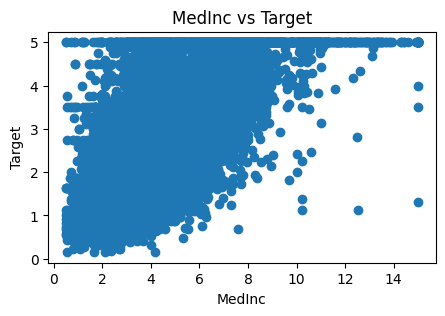

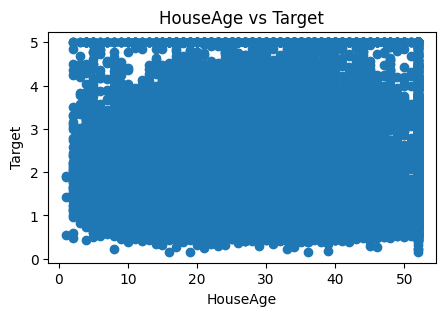

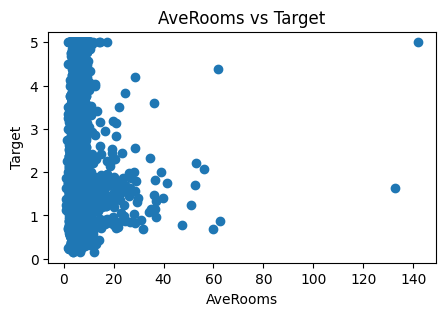

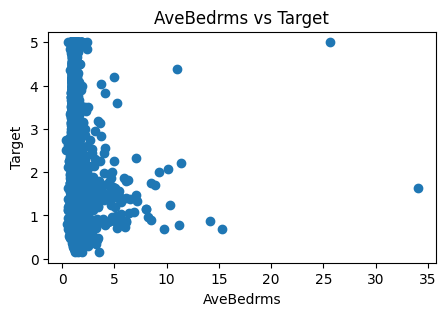

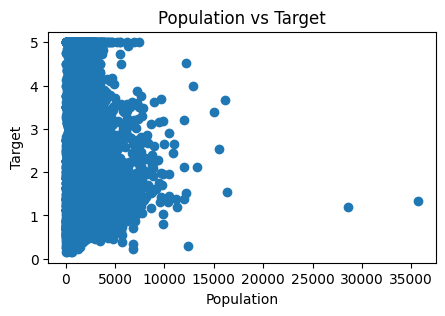

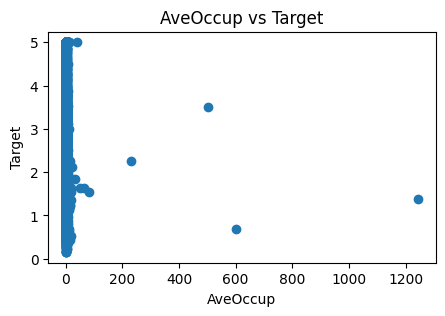

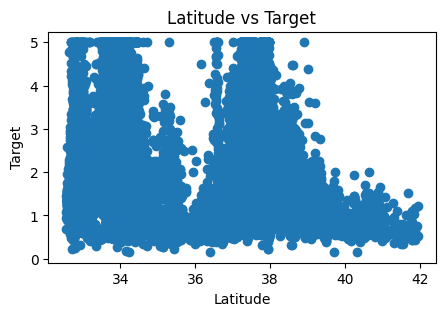

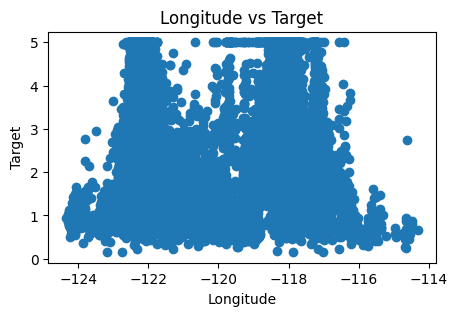

In [19]:
import matplotlib.pyplot as plt

for col in X.columns:
    plt.figure(figsize=(5,3))
    plt.scatter(X[col], y)
    plt.xlabel(col)
    plt.ylabel('Target')
    plt.title(f'{col} vs Target')
    plt.show()

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)


In [10]:
#lets import linear regression model
from sklearn.linear_model import LinearRegression
#using cross validation
from sklearn.model_selection import cross_val_score
lin_reg=LinearRegression()
mse=cross_val_score(lin_reg,X_train,y_train,scoring='neg_mean_squared_error',cv=5)
mean_mse=np.mean(mse)
print(mean_mse)


-0.5230499763383932


In [11]:
from sklearn.metrics import r2_score
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)
print("Test R²:", r2_score(y_test, y_pred))

Test R²: 0.5970494128783949


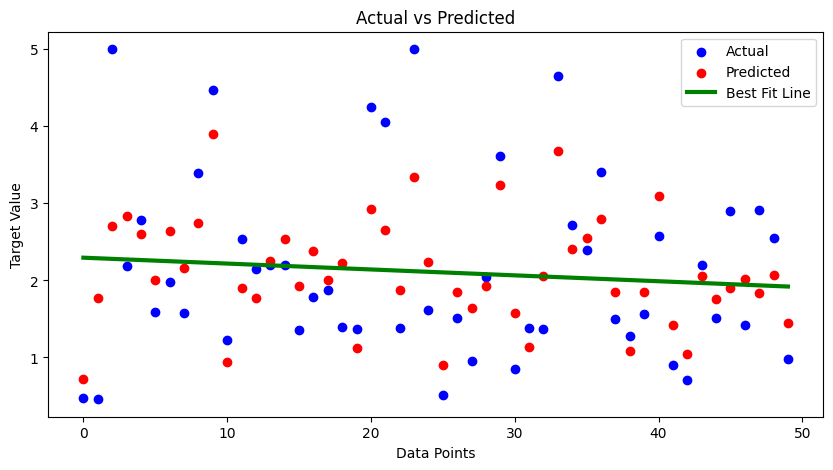

In [26]:
import numpy as np
import matplotlib.pyplot as plt

n = 50

y_true = np.array(y_test[:n])
y_hat = np.array(y_pred[:n])

plt.figure(figsize=(10,5))

plt.scatter(range(n), y_true,
            color='blue', label='Actual')

plt.scatter(range(n), y_hat,
            color='red', label='Predicted')

# Straight best-fit line through predicted points
x = np.arange(n)
m, b = np.polyfit(x, y_hat, 1)

plt.plot(x, m*x + b,
         color='green',
         linewidth=3,
         label='Best Fit Line')

plt.xlabel("Data Points")
plt.ylabel("Target Value")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

In [12]:
# lets use ridge regression
from sklearn.linear_model import Ridge
# for doing hyperparameter tuning(+lamda(slope)pow2)
from sklearn.model_selection import GridSearchCV
ridge=Ridge()
# taking some alpha values
params={'alpha':[1e-15,1e-10,1e-08,0.001,0.01,1,5,10,40,50,100]}
ridge_regressor=GridSearchCV(ridge,params,scoring='neg_mean_squared_error',cv=5)
ridge_regressor.fit(X_train,y_train)


,estimator,Ridge()
,param_grid,"{'alpha': [1e-15, 1e-10, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1e-15


In [13]:
from sklearn.metrics import r2_score
ridge_regressor.fit(X_train, y_train)
y_pred =ridge_regressor.predict(X_test)
print("Test R²:", r2_score(y_test, y_pred))

Test R²: 0.5970494128783952


In [14]:
print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)


{'alpha': 1e-15}
-0.5230499763383933


In [16]:
# lets use lasso regression
from sklearn.linear_model import Lasso
# for doing hyperparameter tuning(+lamda(slope)pow2)
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
# scaling the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
lasso=Lasso()
# taking some alpha values
params={'alpha':[1e-15,1e-10,1e-08,0.001,0.01,1,5,10,40,50,100]}
lasso_regressor=GridSearchCV(lasso,params,scoring='neg_mean_squared_error',cv=5)
lasso_regressor.fit(X_train,y_train)

C:\Users\sridh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.124e+03, tolerance: 1.470e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\sridh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.226e+03, tolerance: 1.471e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\sridh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

,estimator,Lasso()
,param_grid,"{'alpha': [1e-15, 1e-10, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1e-08


In [17]:
from sklearn.metrics import r2_score
lasso_regressor.fit(X_train, y_train)
y_pred =lasso_regressor.predict(X_test)
print("Test R²:", r2_score(y_test, y_pred))

C:\Users\sridh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.124e+03, tolerance: 1.470e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\sridh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.226e+03, tolerance: 1.471e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\sridh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

Test R²: 0.5970494218081677


In [18]:
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)

{'alpha': 1e-08}
-0.5230499762350409
